<img src="./logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Serena Saggion


# Introducción
En este primer trabajo nos enfocamos en el diseño de un generador de señales senoidales mediant euna función que nos permite parametrizar los valores de la amplitud, valor medio, frecuencia, fase, frecuencia de muestreo y la cantidad de muestras.

# Teoria
## Señal senoidal
\begin{equation} x(t) = sen(2\pi ft)\end{equation}
donde *t=nTs* y *Ts=1/fs* entonces
\begin{equation} x(n) = sen(2 \pi nf/fs)\end{equation}, siendo **x(n)** una señal muestreada.
## Teorema de Nyquist
Establece que una señal continua puede ser reconstruida sin pérdida de información a partir de sus muestras si la frecuencia de muestreo **fs** es al menos el doble de la frecuencia **f** presente en la señal.
\begin{equation} fs >= 2f \end{equation}
La frecuencia **fN = fs/2** se denomina *frecuencia de Nyquist* y representa el límite superior de frecuencias que pueden representarse correctamente. Si no se cumple esta condición, se produce el fenómeno de *aliasing*, en el cual las componentes de alta frecuencia se superponen con las de baja frecuencia, generando distorsión e imposibilitando la correcta reconstrucción de la señal original. Nyquist evita la ambigüedad en la representación de señales impidiendo que distintas frecuencias produzcan la misma señal discreta.

<img src="./nyquist.png" style="display:block; width:50%; margin:auto;" />


# Procedimiento
Valores parametrizados:
Vmax = 1 V,
dc = 0 V,
ff = 1 Hz,
ph = 0 rad,
nn = N = 1000,
fs = 1000 Hz.

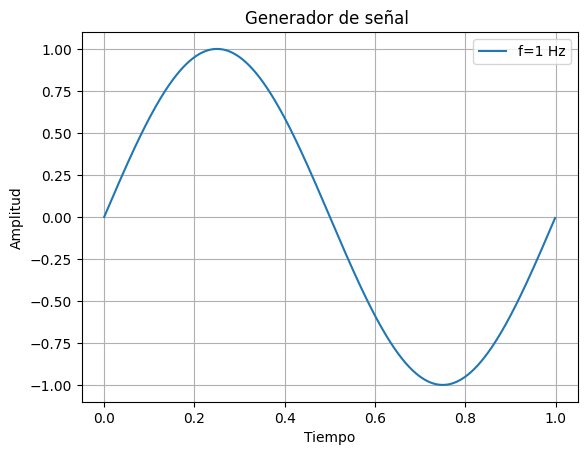

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def mi_sen(vmax, dc, ff, ph, nn, fs):    #función
    Ts=1/fs                              #periodo de muestreo, tiempo entre muestras
    tt=np.arange(nn)*Ts
    xx=dc+vmax*np.sin(2*np.pi*ff*tt + ph)
    return tt,xx

#Teorema de Nyquist: fs>=2f
fs=1000  #frecuencia de muestreo, cantidad de muestras que toma por seg
#fn=fs/2
#ws=2*np.pi*fs
N=1000

tt,xx= mi_sen(vmax=1, dc=0,ff=1, ph=0, nn=N, fs=fs)

plt.title("Generador de señal ")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.plot(tt,xx, label="f=1 Hz")
plt.legend()
plt.grid(True)
plt.show()

A continuación se comparan senoidales parametrizadas idénticamente, exceptuando el valor de la frecuencia. 
- ff = 500 Hz
- ff = 999 Hz
- ff = 1001 Hz
- ff = 2001 Hz

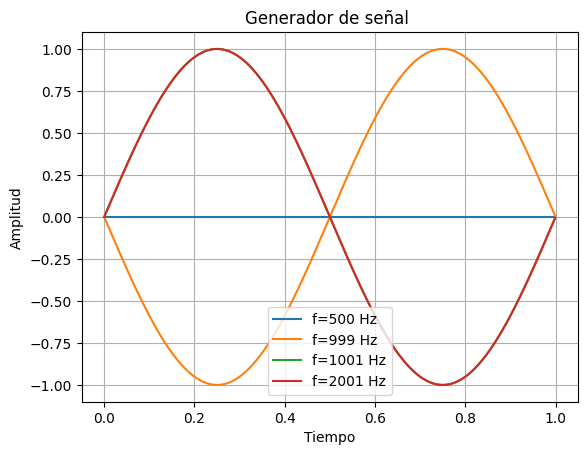

In [39]:
tt,x1= mi_sen(vmax=1, dc=0,ff=500, ph=0, nn=N, fs=fs) #Nyquist
tt,x2= mi_sen(vmax=1, dc=0,ff=999, ph=0, nn=N, fs=fs)
tt,x3= mi_sen(vmax=1, dc=0,ff=1001, ph=0, nn=N, fs=fs)
tt,x4= mi_sen(vmax=1, dc=0,ff=2001, ph=0, nn=N, fs=fs)
#Cuando se pasa de fn la señal comienza a tener fa=fs-f

plt.title("Generador de señal ")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.plot(tt,x1, label="f=500 Hz")
plt.plot(tt,x2, label="f=999 Hz")
plt.plot(tt,x3, label="f=1001 Hz")
plt.plot(tt,x4, label="f=2001 Hz")
plt.legend()
plt.grid(True)
plt.show()

# Análisis de Resultados
Se observa que la señal constante (en azul) corresponde al caso de la frecuencia de Nyquist, es decir, cuando f=fs/2.En este caso, la señal muestreada resulta: sen($\pi$n) = 0 por lo que todas las muestras son nulas y la señal se percibe como constante. Por otro lado, la señal naranja evidencia el fenómeno de aliasing, ya que f supera a fs/2, reemplazando f en la señal muestreada se llega a -sen(2$\pi$n/1000) = -sen(2$\pi$nf/fs), lo que corresponde a la señal de f=1Hz, pero en este caso invertida. De manera similar, al analizar las señales verde y bordo se observa que ambas generan la misma señal que una senoide de 1Hz. Esto ocurre porque sus frecuencias se diferencian en múltiplos enteros de fs **(f1 = f2 +kfs)**.

# Conclusión

# Apéndice

\begin{equation} x(n) = sen(2\pi nf/fs)\end{equation}
si f=2001 y fs=1000
\begin{equation} x(n) = sen(2\pi(2 + 1/1000))\end{equation}
se aplica propiedad trigonometrica sen(a+b):
sen(2\pi n)=0
cos(2\pi n=1
se obtiene
\begin{equation} x(n) = sen(2\pi n/1000)\end{equation}, es decir una senoidal de frecuencia 1 Hz.
